# MeatLens MobileNetV3Small 8-Fold Processed ROI CNN-Only Notebook

This notebook trains the clean MeatLens comparison model using:

- MobileNetV3Small only
- 8-fold cross-rotation
- interval-sampled 8-sample splits
- already processed HSV/LAB-threshold segmented ROI images
- neutralized background
- `224x224` RGB inputs
- no handcrafted RGB/HSV/LAB/GLCM feature branch
- dedicated output root: `training_outputs/mobilenetv3small_8fold_processed_roi_cnn_only/`


Strict accuracy and macro F1 remain the primary metrics. Top-2 accuracy, adjacent accuracy, severe error rate, and ordinal error are kept as secondary transition-aware metrics because pork freshness changes gradually.


In [1]:
import importlib
import inspect

import pandas as pd
from IPython.display import Image as DisplayImage, display

import mobilenetv3small_8fold_processed_roi_cnn_only_lib as segmented6_lib

segmented6_lib = importlib.reload(segmented6_lib)

print("Library source:", segmented6_lib.__file__)
print(
    "Function first lines:",
    {
        "train_mobilenetv3small_8fold_cnn_only_model": segmented6_lib.train_mobilenetv3small_8fold_cnn_only_model.__code__.co_firstlineno,
        "run_single_8fold_cnn_only_experiment": segmented6_lib.run_single_8fold_cnn_only_experiment.__code__.co_firstlineno,
    },
)
print(
    "Function source files:",
    {
        "train_mobilenetv3small_8fold_cnn_only_model": inspect.getsourcefile(segmented6_lib.train_mobilenetv3small_8fold_cnn_only_model),
        "run_single_8fold_cnn_only_experiment": inspect.getsourcefile(segmented6_lib.run_single_8fold_cnn_only_experiment),
    },
)

sanity_optimizer = segmented6_lib.make_optimizer(1e-3)
print("Sanity optimizer type:", type(sanity_optimizer))
print("Sanity optimizer module:", type(sanity_optimizer).__module__)

if inspect.getsourcefile(segmented6_lib.run_single_8fold_cnn_only_experiment) != segmented6_lib.__file__:
    raise RuntimeError("Notebook is not using the module-backed experiment function.")

if "legacy" not in type(sanity_optimizer).__module__:
    raise RuntimeError("Notebook did not load the DirectML-safe legacy Adam optimizer.")

print("Notebook sanity check passed.")

segmented6_lib.ensure_output_dirs()
segmented6_lib.print_library_status()


[INFO] TensorFlow XLA/JIT disabled.
[INFO] TensorFlow XLA/JIT disabled.
[INFO] TensorFlow XLA/JIT disabled.
Library source: e:\Thesis Code\mobilenetv3small_8fold_processed_roi_cnn_only_lib.py
Function first lines: {'train_mobilenetv3small_8fold_cnn_only_model': 1827, 'run_single_8fold_cnn_only_experiment': 1924}
Function source files: {'train_mobilenetv3small_8fold_cnn_only_model': 'e:\\Thesis Code\\mobilenetv3small_8fold_processed_roi_cnn_only_lib.py', 'run_single_8fold_cnn_only_experiment': 'e:\\Thesis Code\\mobilenetv3small_8fold_processed_roi_cnn_only_lib.py'}
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
Sanity optimizer type: <class 'keras.optimizers.legacy.adam.Adam'>
Sanity optimizer module: keras.optimizers.legacy.adam
Notebook sanity check passed.
TF_AVAILABLE = True
SKLEARN_AVAILABLE = True
SKIMAGE_AVAILABLE = True
CV2_AVAILABLE = True
JOBLIB_AVAILABLE = True
SEABORN_AVAILABLE = True
PROJECT_ROOT = e:\Thesis Code
SPLIT_ROOT = e:\Thesis Code\generat

In [2]:
print("USE_TRAINING_AUGMENTATION =", segmented6_lib.USE_TRAINING_AUGMENTATION)


USE_TRAINING_AUGMENTATION = True


In [3]:
split_dfs = segmented6_lib.load_all_cross_rotation_splits()
print("Loaded split keys:", sorted(split_dfs.keys()))
resolved_counts = {
    split_key: int(df["image_path_resolved"].notna().sum())
    for split_key, df in split_dfs.items()
}
resolved_counts


Loaded split keys: ['fold1_test', 'fold1_train', 'fold1_val', 'fold2_test', 'fold2_train', 'fold2_val', 'fold3_test', 'fold3_train', 'fold3_val', 'fold4_test', 'fold4_train', 'fold4_val', 'fold5_test', 'fold5_train', 'fold5_val', 'fold6_test', 'fold6_train', 'fold6_val', 'fold7_test', 'fold7_train', 'fold7_val', 'fold8_test', 'fold8_train', 'fold8_val']


{'fold1_train': 3413,
 'fold1_val': 602,
 'fold1_test': 600,
 'fold2_train': 3413,
 'fold2_val': 602,
 'fold2_test': 600,
 'fold3_train': 3482,
 'fold3_val': 615,
 'fold3_test': 518,
 'fold4_train': 3455,
 'fold4_val': 610,
 'fold4_test': 550,
 'fold5_train': 3413,
 'fold5_val': 602,
 'fold5_test': 600,
 'fold6_train': 3413,
 'fold6_val': 602,
 'fold6_test': 600,
 'fold7_train': 3458,
 'fold7_val': 610,
 'fold7_test': 547,
 'fold8_train': 3413,
 'fold8_val': 602,
 'fold8_test': 600}

In [4]:
metadata_validation_df = segmented6_lib.validate_metadata_mapping(split_dfs)
metadata_validation_df


[WARN] Placeholder metadata used for pork_loin_sample_7: capture_source=unknown, phone_group=unknown
[WARN] Placeholder metadata used for pork_loin_sample_8: capture_source=unknown, phone_group=unknown


,sample_id,sample_number,pork_cut,capture_source,phone_group,rows_found,uses_placeholder_metadata
0,pork_shoulder_sample_1,1,shoulder,researcher_home,old_phone,4800,False
1,pork_shoulder_sample_2,2,shoulder,partner_home,old_phone,4800,False
2,pork_belly_sample_3,3,belly,researcher_home,old_phone,4144,False
3,pork_belly_sample_4,4,belly,partner_home,old_phone,4400,False
4,pork_ham_sample_5,5,ham,researcher_home,new_phone,4800,False
5,pork_ham_sample_6,6,ham,partner_home,new_phone,4800,False
6,pork_loin_sample_7,7,loin,unknown,unknown,4376,True
7,pork_loin_sample_8,8,loin,unknown,unknown,4800,True


In [5]:
quality_bundle = segmented6_lib.build_dataset_quality_summary(split_dfs)
segmented6_lib.print_quality_tables(quality_bundle)
quality_bundle["summary_df"].head(24)



[summary_df]
  split_key  rows  missing_image_path_rows  fresh_count  not_fresh_count  spoiled_count  unique_samples
 fold1_test   600                        0          200              200            200               1
fold1_train  3413                        0         1033             1190           1190               7
  fold1_val   602                        0          182              210            210               7
 fold2_test   600                        0          200              200            200               1
fold2_train  3413                        0         1033             1190           1190               7
  fold2_val   602                        0          182              210            210               7
 fold3_test   518                        0          118              200            200               1
fold3_train  3482                        0         1102             1190           1190               7
  fold3_val   615                        0        

,split_key,rows,missing_image_path_rows,fresh_count,not_fresh_count,spoiled_count,unique_samples
0,fold1_test,600,0,200,200,200,1
1,fold1_train,3413,0,1033,1190,1190,7
2,fold1_val,602,0,182,210,210,7
3,fold2_test,600,0,200,200,200,1
4,fold2_train,3413,0,1033,1190,1190,7
5,fold2_val,602,0,182,210,210,7
6,fold3_test,518,0,118,200,200,1
7,fold3_train,3482,0,1102,1190,1190,7
8,fold3_val,615,0,195,210,210,7
9,fold4_test,550,0,150,200,200,1


In [6]:
shape_audit = segmented6_lib.audit_image_shapes(split_dfs)
shape_audit


already_224_count = 4615
non_224_count = 0
unique_images_checked = 4615


{'already_224_count': 4615, 'non_224_count': 0, 'unique_images_checked': 4615}

Saved sample image figure: e:\Thesis Code\training_outputs\mobilenetv3small_8fold_processed_roi_cnn_only\figures\sample_visualization_grid.png


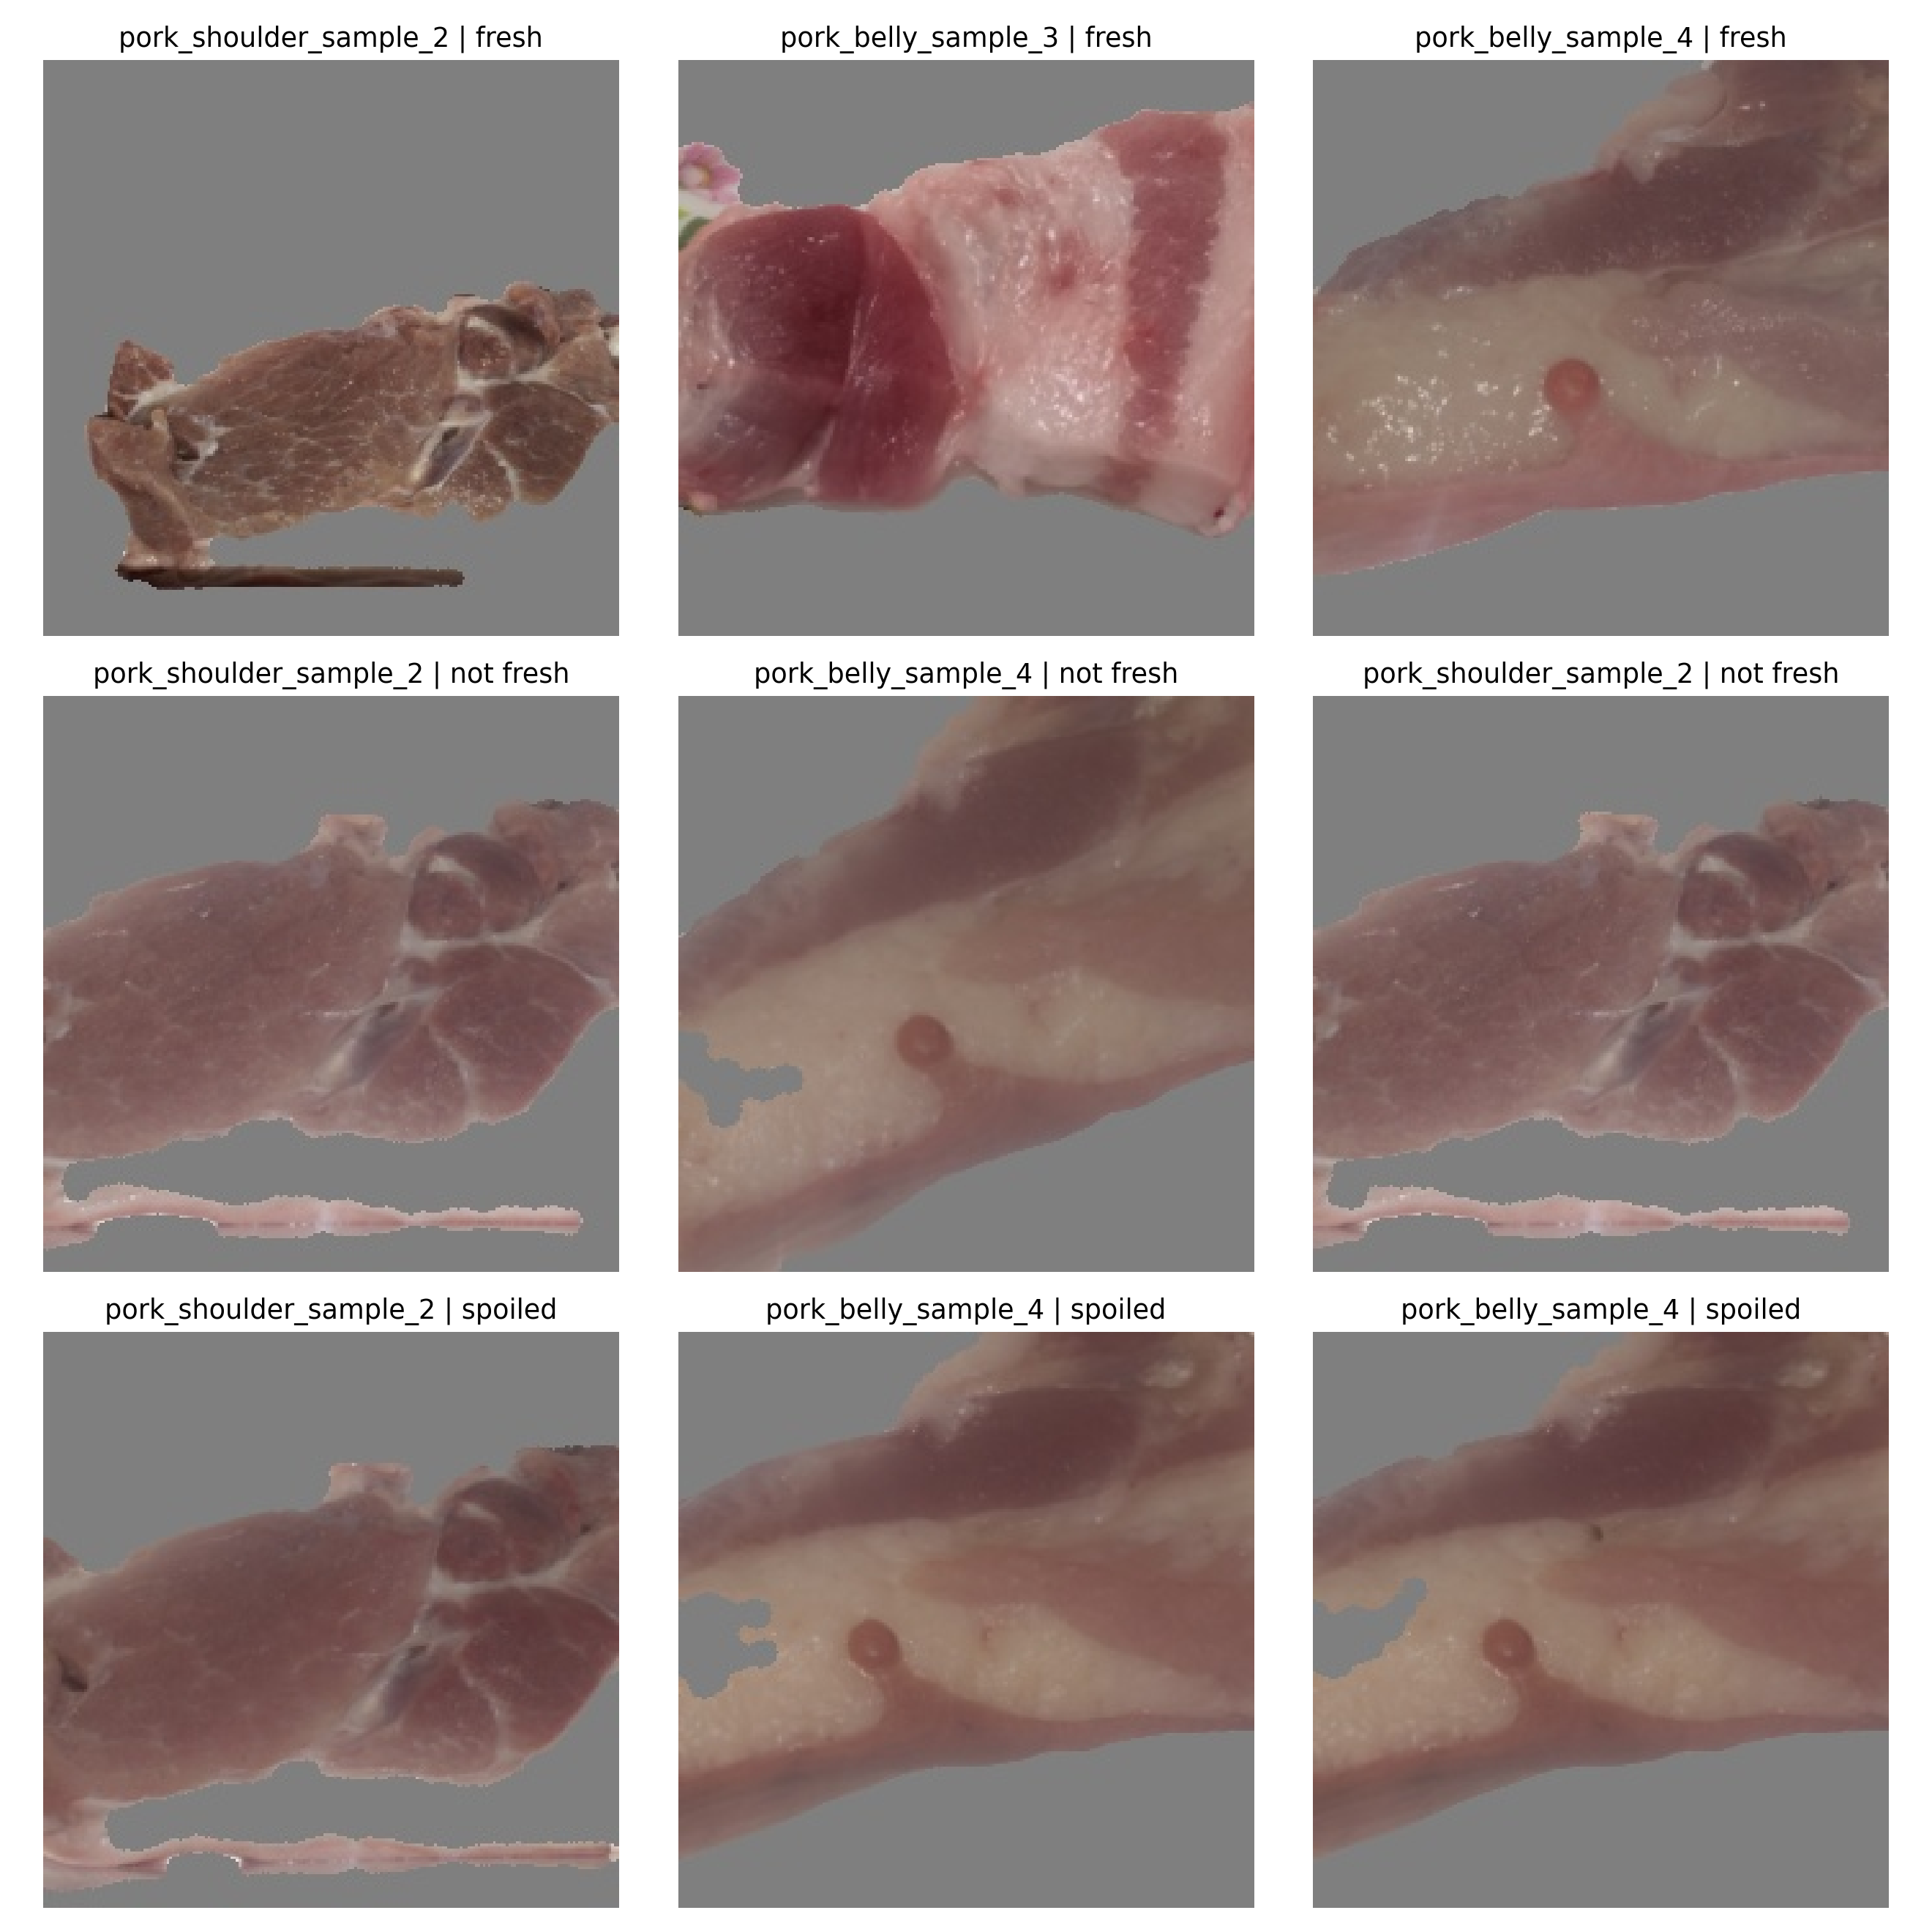

In [7]:
sample_image_figure_path = segmented6_lib.save_sample_visualization(split_dfs)
print("Saved sample image figure:", sample_image_figure_path)
display(DisplayImage(filename=str(sample_image_figure_path)))


In [8]:
print("Seed metrics CSV:", segmented6_lib.PROCESSED_ROI8_SEED_METRICS_PATH)
print("Split root:", segmented6_lib.SPLIT_ROOT)
print("Output root:", segmented6_lib.EXTENSION_OUTPUT_ROOT)
print("Comparison CSV path:", segmented6_lib.PROCESSED_ROI8_COMPARISON_PATH)


Seed metrics CSV: e:\Thesis Code\training_outputs\mobilenetv3small_8fold_processed_roi_cnn_only\processed_roi8_cnn_only_seed_metrics.csv
Split root: e:\Thesis Code\generated_splits\cross_rotation_interval200_8samples_processed_roi
Output root: e:\Thesis Code\training_outputs\mobilenetv3small_8fold_processed_roi_cnn_only
Comparison CSV path: e:\Thesis Code\training_outputs\mobilenetv3small_8fold_processed_roi_cnn_only\processed_roi8_vs_previous_models_comparison.csv


In [9]:
import inspect

source = inspect.getsource(segmented6_lib.train_mobilenetv3small_8fold_cnn_only_model)

print("Contains ModelCheckpoint?", "ModelCheckpoint" in source)
print("Contains load_weights?", "load_weights" in source)
print("Contains .weights.h5?", ".weights.h5" in source)
print("Contains feature_input?", "feature_input" in source)
print("Contains Concatenate?", "Concatenate" in source)
print("Contains StandardScaler?", "StandardScaler" in source)
print("Contains graycomatrix?", "graycomatrix" in source)
print("Contains rgb/hsv/lab/glcm feature extraction?", any(word in source for word in ["glcm", "lab_", "hsv_", "rgb_"]))

print("EXTENSION_FOLDS length:", len(segmented6_lib.EXTENSION_FOLDS))
print("SPLIT_ROOT contains expected folder?", "cross_rotation_interval200_8samples_processed_roi" in str(segmented6_lib.SPLIT_ROOT))
print("IMAGE_CROP_MODE =", segmented6_lib.IMAGE_CROP_MODE)
print("MODEL_INPUT_MODE =", segmented6_lib.MODEL_INPUT_MODE)


Contains ModelCheckpoint? False
Contains load_weights? False
Contains .weights.h5? False
Contains feature_input? False
Contains Concatenate? False
Contains StandardScaler? False
Contains graycomatrix? False
Contains rgb/hsv/lab/glcm feature extraction? False
EXTENSION_FOLDS length: 8
SPLIT_ROOT contains expected folder? True
IMAGE_CROP_MODE = preprocessed_hsv_lab_threshold_roi_224
MODEL_INPUT_MODE = cnn_only


## Optional Comparison

If older result CSVs exist, this section compares:

- segmented 6-fold hybrid
- segmented 6-fold CNN-only
- current 8-fold processed ROI CNN-only


In [10]:
comparison_bundle = segmented6_lib.create_processed_roi8_vs_previous_models_comparison()
if comparison_bundle is not None:
    comparison_bundle["comparison_df"]


[WARN] Missing current result file: e:\Thesis Code\training_outputs\mobilenetv3small_8fold_processed_roi_cnn_only\processed_roi8_cnn_only_seed_metrics.csv


In [11]:
# debug_result = segmented6_lib.run_single_8fold_cnn_only_experiment(
#     fold_name="fold1",
#     seed=42,
# )


## Manual Full Training Cell


In [12]:
MANUAL_CONFIRM_RUN_FULL_TRAINING = True

if MANUAL_CONFIRM_RUN_FULL_TRAINING:
    RUN_EXTENSION_TRAINING = True
    segmented6_lib.RUN_EXTENSION_TRAINING = RUN_EXTENSION_TRAINING
    all_results = segmented6_lib.run_8fold_cnn_only_training()
else:
    print("8-fold processed ROI CNN-only training is ready but not started.")
    print("Set MANUAL_CONFIRM_RUN_FULL_TRAINING = True to train.")


Running processed ROI 8-fold CNN-only experiment: fold1 seed=42
train_images shape=(3413, 224, 224, 3), approx_mb=1959.81
val_images shape=(602, 224, 224, 3), approx_mb=345.68
test_images shape=(600, 224, 224, 3), approx_mb=344.53
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
Epoch 1/8
 - val_f1_macro: 0.8447
107/107 - 11s - loss: 0.9093 - accuracy: 0.5919 - val_loss: 0.4368 - val_accuracy: 0.8422 - val_f1_macro: 0.8447 - lr: 5.0000e-04 - 11s/epoch - 99ms/step
Epoch 2/8
 - val_f1_macro: 0.9098
107/107 - 4s - loss: 0.5065 - accuracy: 0.7902 - val_loss: 0.2765 - val_accuracy: 0.9070 - val_f1_macro: 0.9098 - lr: 5.0000e-04 - 4s/epoch - 38ms/step
Epoch 3/8
 - val_f1_macro: 0.8979
107/107 - 4s - loss: 0.3871 - accuracy: 0.8412 - val_loss: 0.2445 - val_accuracy: 0.8987 - val_f1_macro: 0.8979 - lr: 5.0000e-04 - 4s/epoch - 36ms/step
Epoch 4/8
 - val_f1_macro: 0.9295
107/107 - 4s - loss: 0.3350 - accuracy: 0.8687 - val_loss: 0.1964 - val_accuracy: 0.9286 - val_f1_macr

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpfyirg4mx\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpfyirg4mx\assets


Running processed ROI 8-fold CNN-only experiment: fold1 seed=123
train_images shape=(3413, 224, 224, 3), approx_mb=1959.81
val_images shape=(602, 224, 224, 3), approx_mb=345.68
test_images shape=(600, 224, 224, 3), approx_mb=344.53
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
Epoch 1/8
 - val_f1_macro: 0.8520
107/107 - 9s - loss: 0.8002 - accuracy: 0.6323 - val_loss: 0.4372 - val_accuracy: 0.8538 - val_f1_macro: 0.8520 - lr: 5.0000e-04 - 9s/epoch - 82ms/step
Epoch 2/8
 - val_f1_macro: 0.9140
107/107 - 4s - loss: 0.4880 - accuracy: 0.8054 - val_loss: 0.2732 - val_accuracy: 0.9120 - val_f1_macro: 0.9140 - lr: 5.0000e-04 - 4s/epoch - 34ms/step
Epoch 3/8
 - val_f1_macro: 0.9270
107/107 - 4s - loss: 0.3810 - accuracy: 0.8468 - val_loss: 0.2134 - val_accuracy: 0.9252 - val_f1_macro: 0.9270 - lr: 5.0000e-04 - 4s/epoch - 34ms/step
Epoch 4/8
 - val_f1_macro: 0.9496
107/107 - 4s - loss: 0.3286 - accuracy: 0.8708 - val_loss: 0.1890 - val_accuracy: 0.9485 - val_f1_macro

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmply6_wlq8\assets


...

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpu28y21pt\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpu28y21pt\assets


Running processed ROI 8-fold CNN-only experiment: fold8 seed=2026
train_images shape=(3413, 224, 224, 3), approx_mb=1959.81
val_images shape=(602, 224, 224, 3), approx_mb=345.68
test_images shape=(600, 224, 224, 3), approx_mb=344.53
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
Epoch 1/8
 - val_f1_macro: 0.8872
107/107 - 9s - loss: 0.8810 - accuracy: 0.6124 - val_loss: 0.3723 - val_accuracy: 0.8837 - val_f1_macro: 0.8872 - lr: 5.0000e-04 - 9s/epoch - 81ms/step
Epoch 2/8
 - val_f1_macro: 0.9357
107/107 - 4s - loss: 0.4845 - accuracy: 0.8028 - val_loss: 0.2596 - val_accuracy: 0.9352 - val_f1_macro: 0.9357 - lr: 5.0000e-04 - 4s/epoch - 34ms/step
Epoch 3/8
 - val_f1_macro: 0.9478
107/107 - 4s - loss: 0.3648 - accuracy: 0.8570 - val_loss: 0.1852 - val_accuracy: 0.9468 - val_f1_macro: 0.9478 - lr: 5.0000e-04 - 4s/epoch - 35ms/step
Epoch 4/8
 - val_f1_macro: 0.9539
107/107 - 4s - loss: 0.3101 - accuracy: 0.8808 - val_loss: 0.1652 - val_accuracy: 0.9535 - val_f1_macr

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpwwz5s9kw\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmpwwz5s9kw\assets


## Manual Summary Regeneration Cell


In [15]:
MANUAL_CONFIRM_REGENERATE_SUMMARIES = True

if MANUAL_CONFIRM_REGENERATE_SUMMARIES:
    regenerate_bundle = segmented6_lib.regenerate_metrics_summaries_and_graphs()
else:
    print("Summary regeneration is ready but not started.")


## Completion Check


In [16]:
expected_runs = [(fold, seed) for fold in segmented6_lib.EXTENSION_FOLDS for seed in segmented6_lib.EXTENSION_RUN_SEEDS]
print("Expected run count:", len(expected_runs))

completed_runs = set()
if segmented6_lib.PROCESSED_ROI8_SEED_METRICS_PATH.exists():
    seed_metrics_df = pd.read_csv(segmented6_lib.PROCESSED_ROI8_SEED_METRICS_PATH)
    completed_runs = set(zip(seed_metrics_df["fold_name"].astype(str), seed_metrics_df["seed"].astype(int)))
    print("Completed run count:", len(completed_runs))
else:
    print("Completed run count: 0")

missing_runs = [run for run in expected_runs if run not in completed_runs]
print("Missing runs:", missing_runs)

if segmented6_lib.PROCESSED_ROI8_FAILED_RUNS_PATH.exists():
    failed_runs_df = pd.read_csv(segmented6_lib.PROCESSED_ROI8_FAILED_RUNS_PATH)
    print("Failed runs:")
    display(failed_runs_df)
else:
    print("Failed runs: none logged")


Expected run count: 24
Completed run count: 24
Missing runs: []
Failed runs:


,timestamp,fold_name,seed,model_input_mode,image_crop_mode,error
0,2026-05-19T03:34:38.091489,fold1,42,cnn_only,preprocessed_hsv_lab_threshold_roi_224,InternalError()
1,2026-05-19T03:36:04.980190,fold1,123,cnn_only,preprocessed_hsv_lab_threshold_roi_224,InternalError()
2,2026-05-19T03:37:02.733043,fold1,2026,cnn_only,preprocessed_hsv_lab_threshold_roi_224,InternalError()
3,2026-05-19T03:38:01.328754,fold2,42,cnn_only,preprocessed_hsv_lab_threshold_roi_224,InternalError()
4,2026-05-19T03:39:36.444727,fold2,123,cnn_only,preprocessed_hsv_lab_threshold_roi_224,InternalError()
5,2026-05-19T03:40:51.299162,fold2,2026,cnn_only,preprocessed_hsv_lab_threshold_roi_224,InternalError()


This notebook trains a CNN-only MobileNetV3Small model using the 8-sample processed segmented ROI dataset. The input images are already segmented and resized to 224×224, so the notebook does not perform segmentation or handcrafted feature extraction during training. Strict accuracy and macro F1 are the primary metrics, while top-2 accuracy, adjacent accuracy, severe error rate, and ordinal error are reported as secondary transition-aware metrics because pork freshness is a gradual process. This model is intended for comparison against earlier hybrid and segmented CNN-only experiments.


In [17]:
# Final deployment training section: all 8 validated samples, no test set
# This is for deployment/demo training only.
# Official evaluation remains the 8-fold cross-rotation experiment.

import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

FINAL_DEPLOYMENT_NOTE = (
    "This final model was trained using all 8 validated samples for deployment/demo use. "
    "Official evaluation metrics should be taken from the 8-fold cross-rotation experiment, "
    "not from this final training run."
)

FINAL_OUTPUT_ROOT = Path.cwd() / "training_outputs" / "mobilenetv3small_8samples_final_deployment_cnn_only"
FINAL_MODELS_ROOT = FINAL_OUTPUT_ROOT / "models"
FINAL_ALL_IMAGES_CSV = segmented6_lib.SPLIT_ROOT / "all_sampled_images.csv"

FINAL_MODEL_PATH = FINAL_MODELS_ROOT / "meatlens_final_8samples_cnn_only_mobilenetv3small.h5"
FINAL_TFLITE_PATH = FINAL_MODELS_ROOT / "meatlens_final_8samples_cnn_only_mobilenetv3small.tflite"
FINAL_METADATA_PATH = FINAL_MODELS_ROOT / "meatlens_final_8samples_cnn_only_mobilenetv3small_metadata.json"
FINAL_HISTORY_PATH = FINAL_OUTPUT_ROOT / "final_training_history.csv"
FINAL_VAL_PREDICTIONS_PATH = FINAL_OUTPUT_ROOT / "final_validation_predictions.csv"

FINAL_DEPLOYMENT_SEED = 42
FINAL_VAL_SIZE = 0.15
FINAL_BATCH_SIZE = segmented6_lib.BATCH_SIZE
FINAL_EPOCHS_HEAD = segmented6_lib.EPOCHS_HEAD
FINAL_EPOCHS_FINE = segmented6_lib.EPOCHS_FINE
FINAL_HEAD_LR = segmented6_lib.HEAD_LR
FINAL_FINE_TUNE_LR = segmented6_lib.FINE_TUNE_LR
FINAL_FINE_TUNE_FRACTION = segmented6_lib.FINE_TUNE_FRACTION
FINAL_USE_AUGMENTATION = segmented6_lib.USE_TRAINING_AUGMENTATION

for path_obj in [FINAL_OUTPUT_ROOT, FINAL_MODELS_ROOT]:
    path_obj.mkdir(parents=True, exist_ok=True)

print("FINAL_OUTPUT_ROOT =", FINAL_OUTPUT_ROOT)
print("FINAL_ALL_IMAGES_CSV =", FINAL_ALL_IMAGES_CSV)
print("FINAL_USE_AUGMENTATION =", FINAL_USE_AUGMENTATION)


class FinalImageSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        image_paths,
        labels=None,
        batch_size=32,
        shuffle=False,
        augment=False,
    ):
        self.image_paths = list(image_paths)
        self.labels = None if labels is None else np.asarray(labels, dtype=np.int32)
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.augment = bool(augment)
        self.indices = np.arange(len(self.image_paths))
        self.on_epoch_end()

    def __len__(self):
        if len(self.indices) == 0:
            return 0
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index + 1) * self.batch_size, len(self.indices))
        batch_indices = self.indices[start:end]
        batch_paths = [self.image_paths[idx] for idx in batch_indices]

        batch_uint8 = []
        for path in batch_paths:
            image_uint8 = segmented6_lib.load_preprocessed_hsv_lab_threshold_roi_224(path)
            if self.augment:
                image_uint8 = segmented6_lib.augment_image_uint8(
                    image_uint8,
                    np.random.default_rng(np.random.randint(0, 2**31 - 1)),
                )
            batch_uint8.append(image_uint8)

        batch_uint8 = np.stack(batch_uint8).astype(np.uint8)
        batch_images = segmented6_lib.preprocess_mobilenetv3(batch_uint8.astype(np.float32).copy())
        batch_images = np.asarray(batch_images, dtype=np.float32)

        if self.labels is None:
            return batch_images

        batch_labels = self.labels[batch_indices]
        return batch_images, batch_labels

    def on_epoch_end(self):
        if self.shuffle and len(self.indices) > 0:
            np.random.shuffle(self.indices)


def load_final_deployment_df():
    if not FINAL_ALL_IMAGES_CSV.exists():
        raise FileNotFoundError(f"Missing CSV: {FINAL_ALL_IMAGES_CSV}")

    final_df = segmented6_lib.load_split_dataframe(FINAL_ALL_IMAGES_CSV, "all_samples_final").copy()
    final_df = final_df.loc[final_df["label"].astype(str).isin(segmented6_lib.LABEL_ORDER)].reset_index(drop=True)

    missing_rows = int(final_df["missing_image_path"].sum())
    if missing_rows > 0:
        raise RuntimeError(
            f"Cannot train final deployment model because {missing_rows} image paths could not be resolved."
        )

    processed_root_text = str(Path.cwd() / "processed_hsv_lab_threshold_roi_224").lower().replace("\\", "/")
    path_text = final_df["image_path_resolved"].astype(str).str.lower().str.replace("\\", "/", regex=False)
    bad_path_mask = ~path_text.str.contains("processed_hsv_lab_threshold_roi_224", na=False)
    if bad_path_mask.any():
        bad_count = int(bad_path_mask.sum())
        raise RuntimeError(
            f"Found {bad_count} rows not pointing to processed_hsv_lab_threshold_roi_224. "
            "Do not train until this is fixed."
        )

    return final_df


def split_final_deployment_df(final_df, random_state=42, val_size=0.15):
    stratify_key = (
        final_df["sample_id"].astype(str).str.strip().str.lower()
        + "__"
        + final_df["label"].astype(str).str.strip().str.lower()
    )
    if stratify_key.value_counts().min() < 2:
        print("[WARN] Some sample_id+label groups have fewer than 2 items. Falling back to label-only stratification.")
        stratify_key = final_df["label"].astype(str).str.strip().str.lower()

    train_idx, val_idx = train_test_split(
        final_df.index.to_numpy(),
        test_size=val_size,
        random_state=random_state,
        stratify=stratify_key,
    )

    train_df = final_df.loc[train_idx].copy().reset_index(drop=True)
    val_df = final_df.loc[val_idx].copy().reset_index(drop=True)
    return train_df, val_df


def build_final_history_df(train_info):
    rows = []
    for phase_name, history_key in [("head", "history_head"), ("fine", "history_fine")]:
        history = train_info.get(history_key, {})
        if not history:
            continue
        max_len = max(len(v) for v in history.values())
        for epoch_idx in range(max_len):
            row = {
                "phase": phase_name,
                "epoch_in_phase": epoch_idx + 1,
            }
            for metric_name, metric_values in history.items():
                row[metric_name] = metric_values[epoch_idx] if epoch_idx < len(metric_values) else np.nan
            rows.append(row)
    return pd.DataFrame(rows)


def train_final_8sample_deployment_model():
    segmented6_lib.set_global_seed(FINAL_DEPLOYMENT_SEED)

    final_df = load_final_deployment_df()
    train_df, val_df = split_final_deployment_df(
        final_df,
        random_state=FINAL_DEPLOYMENT_SEED,
        val_size=FINAL_VAL_SIZE,
    )

    train_image_paths = train_df["image_path_resolved"].astype(str).tolist()
    val_image_paths = val_df["image_path_resolved"].astype(str).tolist()

    train_labels = train_df["label"].map(segmented6_lib.LABEL_TO_INDEX).astype(int).to_numpy()
    val_labels = val_df["label"].map(segmented6_lib.LABEL_TO_INDEX).astype(int).to_numpy()

    print("Final deployment dataset sizes")
    print("  total:", len(final_df))
    print("  train:", len(train_df))
    print("  val  :", len(val_df))

    class_weights = segmented6_lib.compute_class_weights_from_labels(train_labels)
    print("Class weights:", class_weights)

    train_sequence = FinalImageSequence(
        image_paths=train_image_paths,
        labels=train_labels,
        batch_size=FINAL_BATCH_SIZE,
        shuffle=True,
        augment=FINAL_USE_AUGMENTATION,
    )
    val_sequence = FinalImageSequence(
        image_paths=val_image_paths,
        labels=val_labels,
        batch_size=FINAL_BATCH_SIZE,
        shuffle=False,
        augment=False,
    )

    model = segmented6_lib.build_mobilenetv3small_cnn_only_model()

    callbacks = [
        segmented6_lib.ValMacroF1Callback(
            val_source=val_sequence,
            val_labels=val_labels,
        ),
        segmented6_lib.keras_callbacks.EarlyStopping(
            monitor="val_f1_macro",
            mode="max",
            patience=4,
            restore_best_weights=True,
        ),
        segmented6_lib.keras_callbacks.ReduceLROnPlateau(
            monitor="val_f1_macro",
            mode="max",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    segmented6_lib.compile_model_safely(
        model,
        optimizer=segmented6_lib.make_optimizer(FINAL_HEAD_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history_head = model.fit(
        train_sequence,
        validation_data=val_sequence,
        epochs=FINAL_EPOCHS_HEAD,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=2,
    )

    segmented6_lib.unfreeze_top_backbone_fraction(
        model,
        fraction=FINAL_FINE_TUNE_FRACTION,
    )
    segmented6_lib.compile_model_safely(
        model,
        optimizer=segmented6_lib.make_optimizer(FINAL_FINE_TUNE_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    history_fine = model.fit(
        train_sequence,
        validation_data=val_sequence,
        epochs=FINAL_EPOCHS_FINE,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=2,
    )

    train_info = {
        "history_head": history_head.history,
        "history_fine": history_fine.history,
        "checkpoint_path": "",
        "class_weights_json": json.dumps(class_weights),
    }

    model.save(FINAL_MODEL_PATH)

    tflite_ok, tflite_size_mb = segmented6_lib.try_convert_to_tflite(model, FINAL_TFLITE_PATH)
    if not tflite_ok and FINAL_TFLITE_PATH.exists():
        FINAL_TFLITE_PATH.unlink(missing_ok=True)

    val_prob = model.predict(val_sequence, verbose=0)
    val_pred = val_prob.argmax(axis=1)

    strict_metrics = segmented6_lib.classification_metrics(val_labels, val_pred)
    val_prediction_df = segmented6_lib.build_transition_prediction_dataframe(val_df, val_labels, val_prob)
    transition_metrics = segmented6_lib.compute_transition_metrics_from_prediction_df(val_prediction_df)

    val_prediction_df["fold_name"] = "final_8samples_deployment"
    val_prediction_df["seed"] = FINAL_DEPLOYMENT_SEED
    val_prediction_df["evaluation_note"] = (
        "Validation split from all 8 samples final deployment training. "
        "Do not use as official generalization claim."
    )
    val_prediction_df.to_csv(FINAL_VAL_PREDICTIONS_PATH, index=False)

    history_df = build_final_history_df(train_info)
    history_df.to_csv(FINAL_HISTORY_PATH, index=False)

    metadata = {
        "model_name": "meatlens_final_8samples_cnn_only_mobilenetv3small",
        "backbone": segmented6_lib.EXTENSION_BACKBONE,
        "model_input_mode": segmented6_lib.MODEL_INPUT_MODE,
        "image_crop_mode": segmented6_lib.IMAGE_CROP_MODE,
        "input_shape": list(segmented6_lib.INPUT_SHAPE),
        "target_size": list(segmented6_lib.TARGET_SIZE),
        "label_order": segmented6_lib.LABEL_ORDER,
        "label_to_index": segmented6_lib.LABEL_TO_INDEX,
        "index_to_label": segmented6_lib.INDEX_TO_LABEL,
        "split_mode": "final_8samples_train_val_only",
        "train_count": int(len(train_df)),
        "val_count": int(len(val_df)),
        "seed": FINAL_DEPLOYMENT_SEED,
        "class_weights": class_weights,
        "validation_accuracy": float(strict_metrics["accuracy"]),
        "validation_macro_precision": float(strict_metrics["macro_precision"]),
        "validation_macro_recall": float(strict_metrics["macro_recall"]),
        "validation_macro_f1": float(strict_metrics["macro_f1"]),
        "validation_top_2_accuracy": float(transition_metrics["top_2_accuracy"]),
        "validation_adjacent_accuracy": float(transition_metrics["adjacent_accuracy"]),
        "validation_severe_error_rate": float(transition_metrics["severe_error_rate"]),
        "validation_mean_absolute_ordinal_error": float(transition_metrics["mean_absolute_ordinal_error"]),
        "model_path": str(FINAL_MODEL_PATH),
        "tflite_path": str(FINAL_TFLITE_PATH) if FINAL_TFLITE_PATH.exists() else "",
        "training_output_root": str(FINAL_OUTPUT_ROOT),
        "preprocessing_note": (
            "Input images are preprocessed HSV/LAB-threshold segmented ROI images with neutralized "
            "background, expected to be 224x224 RGB before MobileNetV3Small preprocessing. "
            "No handcrafted RGB/HSV/LAB/GLCM feature branch is used."
        ),
        "deployment_note": FINAL_DEPLOYMENT_NOTE,
        "timestamp": pd.Timestamp.now().isoformat(),
    }
    FINAL_METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    print()
    print(FINAL_DEPLOYMENT_NOTE)
    print("Saved model:", FINAL_MODEL_PATH)
    print("Saved tflite:", FINAL_TFLITE_PATH if FINAL_TFLITE_PATH.exists() else "[not created]")
    print("Saved metadata:", FINAL_METADATA_PATH)
    print("Saved history:", FINAL_HISTORY_PATH)
    print("Saved val predictions:", FINAL_VAL_PREDICTIONS_PATH)

    return {
        "model": model,
        "train_df": train_df,
        "val_df": val_df,
        "train_info": train_info,
        "history_df": history_df,
        "val_prediction_df": val_prediction_df,
        "strict_metrics": strict_metrics,
        "transition_metrics": transition_metrics,
        "metadata": metadata,
    }

FINAL_OUTPUT_ROOT = e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only
FINAL_ALL_IMAGES_CSV = e:\Thesis Code\generated_splits\cross_rotation_interval200_8samples_processed_roi\all_sampled_images.csv
FINAL_USE_AUGMENTATION = True


In [18]:
MANUAL_CONFIRM_TRAIN_FINAL_8SAMPLE_MODEL = True

if MANUAL_CONFIRM_TRAIN_FINAL_8SAMPLE_MODEL:
    final_8sample_bundle = train_final_8sample_deployment_model()
else:
    print("Final 8-sample deployment training section is ready but not started.")
    print("Set MANUAL_CONFIRM_TRAIN_FINAL_8SAMPLE_MODEL = True to train.")
    print(FINAL_DEPLOYMENT_NOTE)

Final deployment dataset sizes
  total: 4615
  train: 3922
  val  : 693
Class weights: {0: 1.0876317249029395, 1: 0.9612745098039216, 2: 0.9612745098039216}
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
Epoch 1/8
 - val_f1_macro: 0.8829
123/123 - 43s - loss: 0.8608 - accuracy: 0.6137 - val_loss: 0.3739 - val_accuracy: 0.8831 - val_f1_macro: 0.8829 - lr: 5.0000e-04 - 43s/epoch - 349ms/step
Epoch 2/8
 - val_f1_macro: 0.9026
123/123 - 38s - loss: 0.4754 - accuracy: 0.7991 - val_loss: 0.2634 - val_accuracy: 0.9004 - val_f1_macro: 0.9026 - lr: 5.0000e-04 - 38s/epoch - 307ms/step
Epoch 3/8
 - val_f1_macro: 0.9431
123/123 - 39s - loss: 0.3722 - accuracy: 0.8531 - val_loss: 0.1911 - val_accuracy: 0.9423 - val_f1_macro: 0.9431 - lr: 5.0000e-04 - 39s/epoch - 314ms/step
Epoch 4/8
 - val_f1_macro: 0.9399
123/123 - 39s - loss: 0.3242 - accuracy: 0.8669 - val_loss: 0.1702 - val_accuracy: 0.9394 - val_f1_macro: 0.9399 - lr: 5.0000e-04 - 39s/epoch - 317ms/step
Epoch 5/8
 - v

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp4imp8rjo\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp4imp8rjo\assets



This final model was trained using all 8 validated samples for deployment/demo use. Official evaluation metrics should be taken from the 8-fold cross-rotation experiment, not from this final training run.
Saved model: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\models\meatlens_final_8samples_cnn_only_mobilenetv3small.h5
Saved tflite: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\models\meatlens_final_8samples_cnn_only_mobilenetv3small.tflite
Saved metadata: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\models\meatlens_final_8samples_cnn_only_mobilenetv3small_metadata.json
Saved history: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\final_training_history.csv
Saved val predictions: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\final_validation_predictions.csv


In [20]:
FINAL_DEPLOYMENT_SEEDS = [123, 2026]

MANUAL_CONFIRM_TRAIN_FINAL_8SAMPLE_MODEL = True

if MANUAL_CONFIRM_TRAIN_FINAL_8SAMPLE_MODEL:
    final_8sample_results = {}

    for final_seed in FINAL_DEPLOYMENT_SEEDS:
        print("=" * 80)
        print(f"Training final 8-sample deployment model with seed={final_seed}")
        print("=" * 80)

        FINAL_DEPLOYMENT_SEED = final_seed

        FINAL_MODEL_PATH = FINAL_MODELS_ROOT / f"meatlens_final_8samples_cnn_only_mobilenetv3small_seed{final_seed}.h5"
        FINAL_TFLITE_PATH = FINAL_MODELS_ROOT / f"meatlens_final_8samples_cnn_only_mobilenetv3small_seed{final_seed}.tflite"
        FINAL_METADATA_PATH = FINAL_MODELS_ROOT / f"meatlens_final_8samples_cnn_only_mobilenetv3small_seed{final_seed}_metadata.json"
        FINAL_HISTORY_PATH = FINAL_OUTPUT_ROOT / f"final_training_history_seed{final_seed}.csv"
        FINAL_VAL_PREDICTIONS_PATH = FINAL_OUTPUT_ROOT / f"final_validation_predictions_seed{final_seed}.csv"

        final_8sample_results[final_seed] = train_final_8sample_deployment_model()

        if segmented6_lib.TF_AVAILABLE:
            tf.keras.backend.clear_session()
        gc.collect()

    print("Completed final deployment training for seeds:", FINAL_DEPLOYMENT_SEEDS)
else:
    print("Final 8-sample deployment training section is ready but not started.")
    print("Set MANUAL_CONFIRM_TRAIN_FINAL_8SAMPLE_MODEL = True to train.")
    print("Seeds to run:", FINAL_DEPLOYMENT_SEEDS)
    print(FINAL_DEPLOYMENT_NOTE)

Training final 8-sample deployment model with seed=123
Final deployment dataset sizes
  total: 4615
  train: 3922
  val  : 693
Class weights: {0: 1.0876317249029395, 1: 0.9612745098039216, 2: 0.9612745098039216}
[INFO] Using tf.keras.optimizers.legacy.Adam for DirectML compatibility.
Epoch 1/8
 - val_f1_macro: 0.8848
123/123 - 59s - loss: 0.8040 - accuracy: 0.6341 - val_loss: 0.4094 - val_accuracy: 0.8817 - val_f1_macro: 0.8848 - lr: 5.0000e-04 - 59s/epoch - 476ms/step
Epoch 2/8
 - val_f1_macro: 0.9176
123/123 - 43s - loss: 0.4668 - accuracy: 0.8180 - val_loss: 0.2680 - val_accuracy: 0.9177 - val_f1_macro: 0.9176 - lr: 5.0000e-04 - 43s/epoch - 347ms/step
Epoch 3/8
 - val_f1_macro: 0.9287
123/123 - 44s - loss: 0.3518 - accuracy: 0.8644 - val_loss: 0.2016 - val_accuracy: 0.9278 - val_f1_macro: 0.9287 - lr: 5.0000e-04 - 44s/epoch - 359ms/step
Epoch 4/8
 - val_f1_macro: 0.9426
123/123 - 41s - loss: 0.3255 - accuracy: 0.8735 - val_loss: 0.1796 - val_accuracy: 0.9423 - val_f1_macro: 0.9426 -

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmplj4q3tz4\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmplj4q3tz4\assets



This final model was trained using all 8 validated samples for deployment/demo use. Official evaluation metrics should be taken from the 8-fold cross-rotation experiment, not from this final training run.
Saved model: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\models\meatlens_final_8samples_cnn_only_mobilenetv3small_seed123.h5
Saved tflite: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\models\meatlens_final_8samples_cnn_only_mobilenetv3small_seed123.tflite
Saved metadata: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\models\meatlens_final_8samples_cnn_only_mobilenetv3small_seed123_metadata.json
Saved history: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\final_training_history_seed123.csv
Saved val predictions: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\final_validation_predictions_seed123.cs

INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp_p_szr8k\assets


INFO:tensorflow:Assets written to: C:\Users\jazre\AppData\Local\Temp\tmp_p_szr8k\assets



This final model was trained using all 8 validated samples for deployment/demo use. Official evaluation metrics should be taken from the 8-fold cross-rotation experiment, not from this final training run.
Saved model: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\models\meatlens_final_8samples_cnn_only_mobilenetv3small_seed2026.h5
Saved tflite: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\models\meatlens_final_8samples_cnn_only_mobilenetv3small_seed2026.tflite
Saved metadata: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\models\meatlens_final_8samples_cnn_only_mobilenetv3small_seed2026_metadata.json
Saved history: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\final_training_history_seed2026.csv
Saved val predictions: e:\Thesis Code\training_outputs\mobilenetv3small_8samples_final_deployment_cnn_only\final_validation_predictions_seed20